# LEC04. 딥러닝 CNN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------- ML모델 
from sklearn.ensemble import RandomForestClassifier 
#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#----------------------------------------------------------------------------------- 평가
from sklearn.metrics  import accuracy_score,      f1_score


import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

## Data load

In [2]:
from tensorflow.keras.datasets.mnist import load_data

In [3]:
(x_train, y_train), (x_test, y_test) = load_data(path='mnist.npz')
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

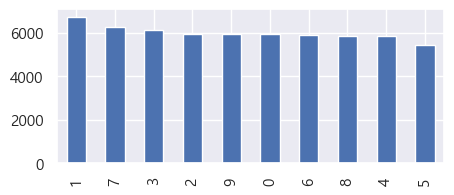

In [5]:
plt.figure(figsize=(5,2))
pd.Series(y_train).value_counts().plot(kind='bar')
plt.show()

## Date Set

In [6]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

## EDA

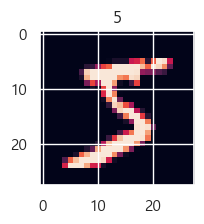

In [7]:
plt.figure(figsize=(5,2))
plt.imshow(x_train[0])
plt.title(y_train[0])
plt.show()

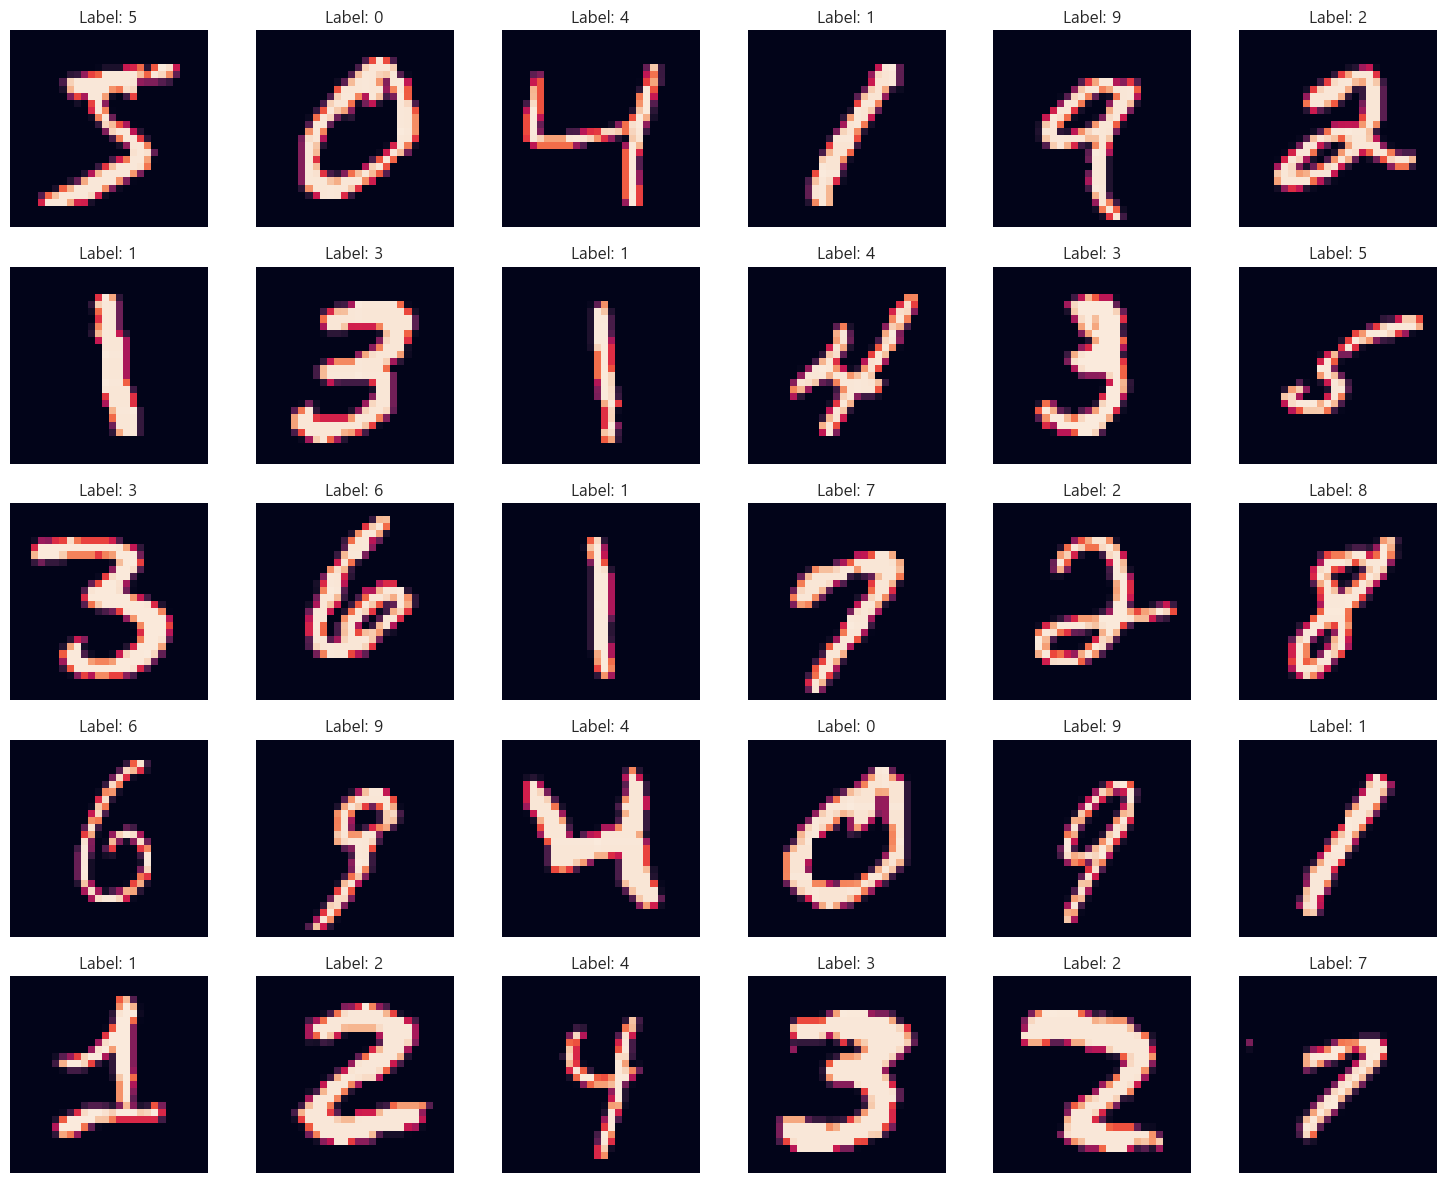

In [10]:
import matplotlib.pyplot as plt

# 전체 피규어 크기 설정 (가로, 세로)
plt.figure(figsize=(15, 12))

for i in range(30):
    # 5행 6열 구조로 서브플롯 생성
    plt.subplot(5, 6, i + 1)
    
    # i번째 이미지 출력
    plt.imshow(x_train[i])
    
    # i번째 레이블(정답)을 타이틀로 표시
    plt.title(f"Label: {y_train[i]}")
    
    # 그래프 축 눈금 제거 (깔끔한 시각화를 위해)
    plt.axis('off')

# 레이아웃 겹침 방지 및 출력
plt.tight_layout()
plt.show()

## 전처리 & 가공
 * 컬러, 노이즈, 채도, 리사이징으로 보정
 * 픽셀 -> (0 ~ 255)스케일링 필요 -> MinMaxScaler(모든 데이터를 0 ~ 1사이 숫자로) ;
           MinMaxScaler 대신 사용하는 방식 x_train = x_train / 255.0
 * 이미지 증강( augmentation)

In [11]:
x_train =x_train/255

In [12]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [13]:
x_test = x_test/255

## 모델링

In [15]:
x_train, x_test = x_train.reshape(-1, 28*28), x_test.reshape(-1, 28*28)
x_train.shape, x_test.shape

((60000, 784), (10000, 784))

### 머신러닝

In [17]:
model = RandomForestClassifier (random_state=4545)
model.fit(x_train, y_train)

NameError: name 'modle' is not defined

In [18]:
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
accuracy

0.9693

### 딥러닝

In [19]:
model = Sequential([
    Dense(units=10, activation="relu" , input_dim=784  ),   #----- input layer
    Dense(units=16, activation="relu"                ),   #----- hidden layer 3
    Dense(units=24, activation="relu"                ),    
    Dense(units=8,  activation="relu"                ),
    Dense(units=10,  activation="softmax"             )    #----- output layer   
 ])

In [20]:
model.compile(loss="sparse_categorical_crossentropy" , optimizer="adam",  metrics=["accuracy"])   #-------------------- l o m

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │           7,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │              90 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,724 (34.08 KB)

 Trainable params: 8,724 (34.08 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
res = model.fit(x_train,y_train,     epochs=50 ,   validation_data = (x_test,y_test)  )
# res
loss,acc = model.evaluate(x_test, y_test)
print(f"acc : {acc:.4f} , loss:{loss:.4f} " )

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8049 - loss: 0.6331 - val_accuracy: 0.8911 - val_loss: 0.3623
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9025 - loss: 0.3304 - val_accuracy: 0.9102 - val_loss: 0.3029
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9178 - loss: 0.2804 - val_accuracy: 0.9140 - val_loss: 0.2921
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9252 - loss: 0.2485 - val_accuracy: 0.9273 - val_loss: 0.2443
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9324 - loss: 0.2280 - val_accuracy: 0.9282 - val_loss: 0.2463
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9343 - loss: 0.2154 - val_accuracy: 0.9332 - val_loss: 0.2238
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9386 - loss: 0.2040 - val_accuracy: 0.9342 - val_loss: 0.2270
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9411 - loss: 0.1953 - 

## 오답 체크

In [24]:
proba = model.predict(x_test)
pred = np.argmax(proba, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step


In [25]:
pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
cm_df = pd.DataFrame(cm, 
                     index=[f'Actual {i}' for i in range(10)], 
                     columns=[f'Predict {i}' for i in range(10)])

cm_df.index.name = 'Actual(True)'
cm_df.columns.name = 'Predicted'

cm_df

Predicted,Predict 0,Predict 1,Predict 2,Predict 3,Predict 4,Predict 5,Predict 6,Predict 7,Predict 8,Predict 9
Actual(True),,,,,,,,,,
Actual 0,962,0,5,1,0,2,4,2,3,1
Actual 1,0,1113,3,4,0,2,2,4,7,0
Actual 2,12,6,975,5,7,4,5,9,9,0
Actual 3,1,2,14,929,0,40,1,8,14,1
Actual 4,1,0,7,0,938,1,8,1,2,24
Actual 5,7,2,3,28,4,828,6,2,8,4
Actual 6,17,1,3,0,10,14,911,0,2,0
Actual 7,1,8,17,8,4,1,0,969,1,19
Actual 8,9,3,6,13,6,18,10,6,898,5


In [31]:
import pandas as pd

# 1. x_test(넘파이 배열)의 행(row)들을 리스트로 묶음 (원소는 여전히 ndarray)
# 이 과정은 단순한 참조 복사 수준이라 매우 빠릅니다.
image_col = list(x_test)

# 2. 딕셔너리로 묶어 데이터프레임 생성
# 인덱스는 0부터 len(x_test)-1까지 자동으로 부여되며, 이는 원본 배열의 순서와 일치합니다.
oxdf = pd.DataFrame({
    'Actual': y_test.flatten(),
    'Predict': pred.flatten(),
    'Image_Data': image_col
})

# 3. 오답 필터링
oxdf = oxdf[oxdf['Actual'] != oxdf['Predict']]

print(oxdf.head())

     Actual  Predict  \
18        3        8   
72        2        3   
87        3        5   
149       2        4   
151       9        8   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    Image_Data  
18   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0

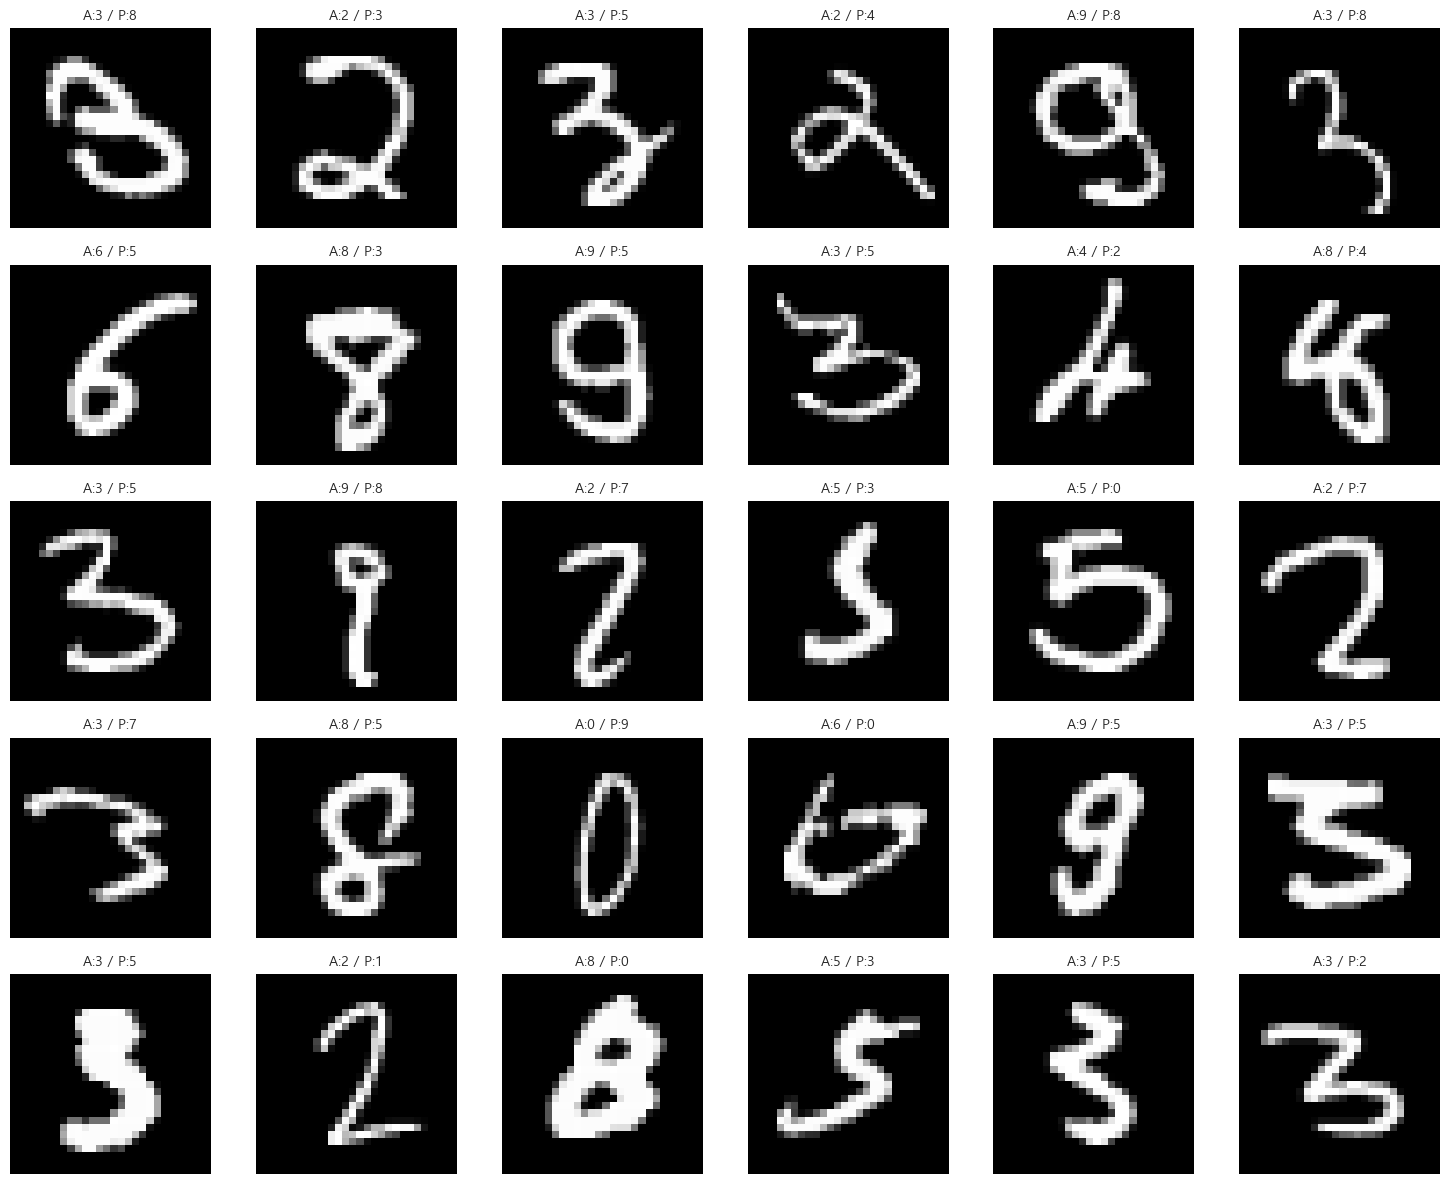

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 전체 피규어 크기 설정
plt.figure(figsize=(15, 12))

# oxdf에서 상위 30개의 데이터를 가져옴
# iloc을 사용하여 필터링된 데이터 중 순서대로 30개를 선택
for i in range(30):
    plt.subplot(5, 6, i + 1)
    
    # 1. Image_Data 컬럼에서 넘파이 배열 추출 및 28x28 재구성
    # 리스트 내 넘파이 객체 상태이므로 바로 reshape 가능
    img = np.array(oxdf.iloc[i]['Image_Data']).reshape(28, 28)
    
    # 2. 실제값(A)과 예측값(P) 가져오기
    actual = oxdf.iloc[i]['Actual']
    predict = oxdf.iloc[i]['Predict']
    
    # 3. 이미지 출력
    plt.imshow(img, cmap='gray')
    
    # 4. 타이틀에 실제값과 예측값 표시 (구분을 위해 색상이나 텍스트 추가 가능)
    plt.title(f"A:{actual} / P:{predict}", fontsize=10)
    
    plt.axis('off')

plt.tight_layout()
plt.show()

## CNN

In [34]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [38]:
model = Sequential([
    Conv2D(filters=16, kernel_size=(5,5), strides=(1,1), padding='valid', activation='relu', input_shape=(28,28,1) ),
    MaxPooling2D(pool_size=(2,2) ),
    Conv2D(filters=24, kernel_size=(5,5), activation='relu' ),
    MaxPooling2D(pool_size=(2,2) ),
    Flatten(),
    Dense(units=16, activation='relu'),
    Dense(units=10, activation='softmax', input_dim=784),
    
])

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 16)          │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 24)            │           9,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 4, 4, 24)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │           6,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,370 (63.95 KB)

 Trainable params: 16,370 (63.95 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
(x_train, y_train), (x_test, y_test) = load_data(path='mnist.npz')
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [41]:
x_train, x_test = x_train/255, x_test/255
x_train, x_test = x_train.reshape(-1,28,28,1), x_test.reshape(-1,28,28,1)

In [42]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28, 1), (60000,), (10000, 28, 28, 1), (10000,))

In [44]:
model.compile(loss="sparse_categorical_crossentropy" , optimizer="adam",  metrics=["accuracy"])   #-------------------- l o m

In [45]:
res = model.fit(x_train,y_train,     epochs=50 ,   validation_data = (x_test,y_test)  )
# res
loss,acc = model.evaluate(x_test, y_test)
print(f"acc : {acc:.4f} , loss:{loss:.4f} " )

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9276 - loss: 0.2355 - val_accuracy: 0.9756 - val_loss: 0.0809
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9778 - loss: 0.0715 - val_accuracy: 0.9863 - val_loss: 0.0435
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9839 - loss: 0.0517 - val_accuracy: 0.9891 - val_loss: 0.0369
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9876 - loss: 0.0399 - val_accuracy: 0.9875 - val_loss: 0.0389
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9893 - loss: 0.0336 - val_accuracy: 0.9878 - val_loss: 0.0400
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9916 - loss: 0.0267 - val_accuracy: 0.9887 - val_loss: 0.0368
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9926 - loss: 0.0236 - val_accuracy: 0.9888 - val_loss: 0.0361
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9936 - loss: 0.0199 - 

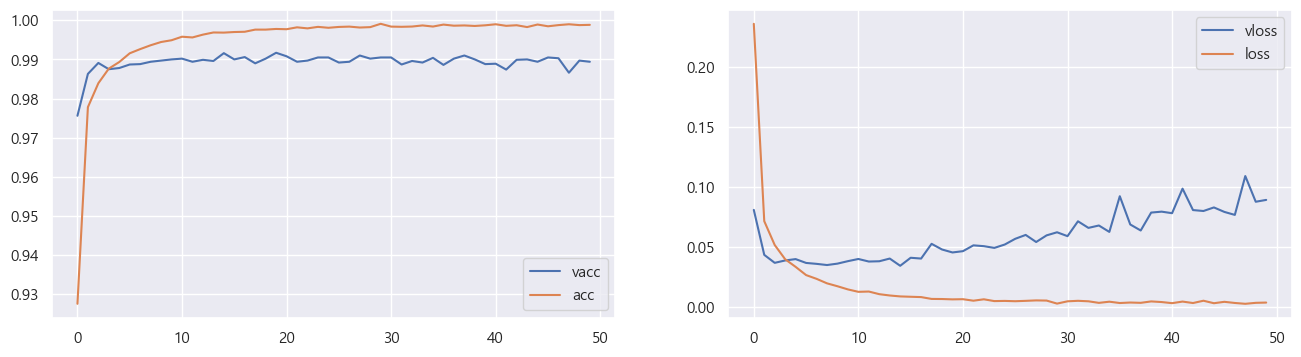

In [46]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(50), vacc , label="vacc")
plt.plot(range(50), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(50),vloss , label="vloss")
plt.plot(range(50),loss  , label="loss")
plt.legend()
plt.show()